## Logistic Regression

In [1]:
import pandas as pd
import numpy as np

full_data = pd.read_csv('US-pumpkins.csv')
full_data.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [2]:
columns = ['City Name', 'Package', 'Variety', 'Origin', 'Color', 'Item Size']
new_data = full_data.loc[:, columns]

new_data.dropna(inplace=True)
new_data.head()

,City Name,Package,Variety,Origin,Color,Item Size
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,ORANGE,med
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,ORANGE,med
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,ORANGE,lge
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,ORANGE,lge
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,ORANGE,med


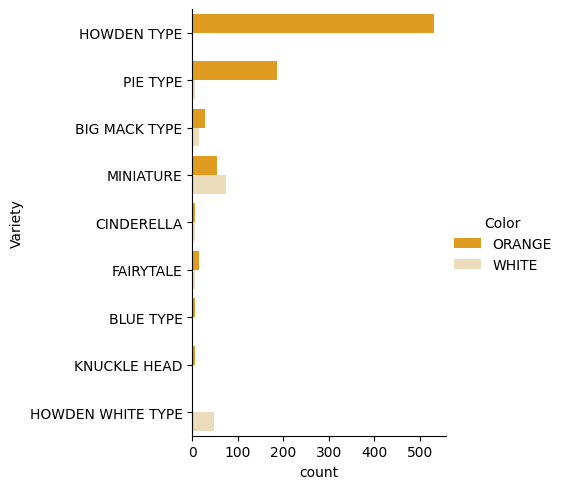

In [3]:
import seaborn as sns
palette = {
    'ORANGE' : 'orange',
    'WHITE' :  'wheat',
}
sns.catplot(data=new_data, y="Variety", hue="Color", kind="count", palette=palette,)


# Data pre-processing

In [4]:
new_data['Item Size'].unique()

array(['med', 'lge', 'sml', 'xlge', 'med-lge', 'jbo', 'exjbo'],
      dtype=object)

In [5]:
from sklearn.preprocessing import OrdinalEncoder
item_size_categories = [['sml','med','med-lge', 'lge',  'xlge',  'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

In [6]:
from sklearn.preprocessing import OneHotEncoder
nominal_features = ['City Name', 'Package', 'Variety', 'Origin']
nominal_encoder = OneHotEncoder(sparse_output=False)


In [7]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features),
    ('nom', nominal_encoder, nominal_features)
])
preprocessor.set_output(transform='pandas')
encoded_features = preprocessor.fit_transform(new_data)
encoded_features.head()

,ord__Item Size,nom__City Name_ATLANTA,nom__City Name_BALTIMORE,nom__City Name_BOSTON,nom__City Name_CHICAGO,nom__City Name_COLUMBIA,nom__City Name_DALLAS,nom__City Name_DETROIT,nom__City Name_LOS ANGELES,nom__City Name_MIAMI,...,nom__Origin_MICHIGAN,nom__Origin_NEW JERSEY,nom__Origin_NEW YORK,nom__Origin_NORTH CAROLINA,nom__Origin_OHIO,nom__Origin_PENNSYLVANIA,nom__Origin_TENNESSEE,nom__Origin_TEXAS,nom__Origin_VERMONT,nom__Origin_VIRGINIA
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(new_data['Color'])
encoded_data = encoded_features.assign(Color=encoded_label)
encoded_data.head()

,ord__Item Size,nom__City Name_ATLANTA,nom__City Name_BALTIMORE,nom__City Name_BOSTON,nom__City Name_CHICAGO,nom__City Name_COLUMBIA,nom__City Name_DALLAS,nom__City Name_DETROIT,nom__City Name_LOS ANGELES,nom__City Name_MIAMI,...,nom__Origin_NEW JERSEY,nom__Origin_NEW YORK,nom__Origin_NORTH CAROLINA,nom__Origin_OHIO,nom__Origin_PENNSYLVANIA,nom__Origin_TENNESSEE,nom__Origin_TEXAS,nom__Origin_VERMONT,nom__Origin_VIRGINIA,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


C:\Users\PC\AppData\Local\Temp\ipykernel_12988\3767645518.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=new_data, x='Item Size', y='Color', row='Variety', kind='box', orient="h",


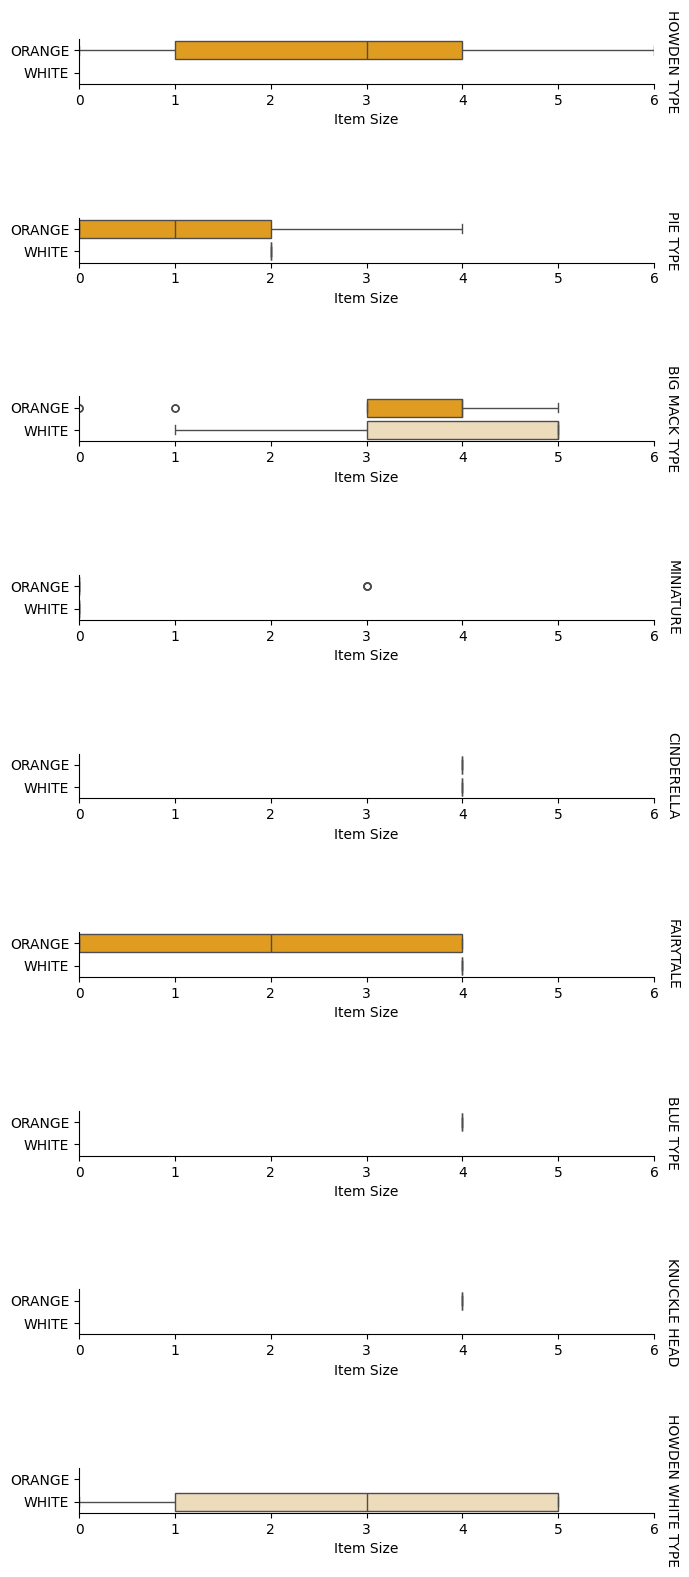

In [9]:
palette = {
    'ORANGE':'orange',
    'WHITE' :'wheat',
}
new_data['Item Size'] = encoded_data['ord__Item Size']
g = sns.catplot(data=new_data, x='Item Size', y='Color', row='Variety', kind='box', orient="h",
                sharex=False, margin_titles=True, height=1.8, aspect=4, palette=palette)
g.set(xlabel='Item Size', ylabel="").set(xlim=(0,6))
g.set_titles(row_template = '{row_name}')

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 63.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Color', ylabel='ord__Item Size'>

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 79.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


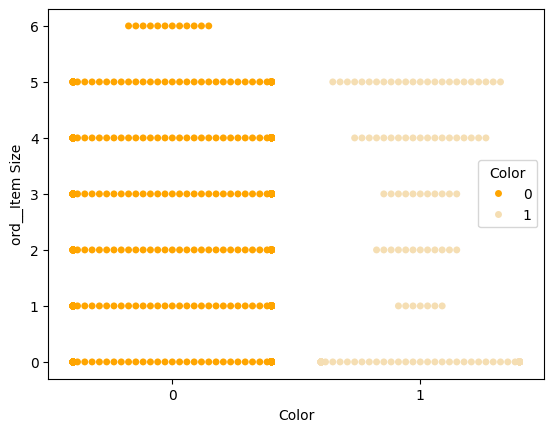

In [10]:
palette = {
    0: 'orange',
    1: 'wheat'
}
sns.swarmplot(x="Color",y='ord__Item Size', data=encoded_data, palette=palette, hue="Color")

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression
x = encoded_data[encoded_data.columns.difference(['Color'])]
y = encoded_data['Color']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"F1-score: {f1_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))
print('Predicteed labels:', y_pred)



F1-score: 0.7457627118644068
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicteed labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]


In [12]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[162,   4],
       [ 11,  22]])

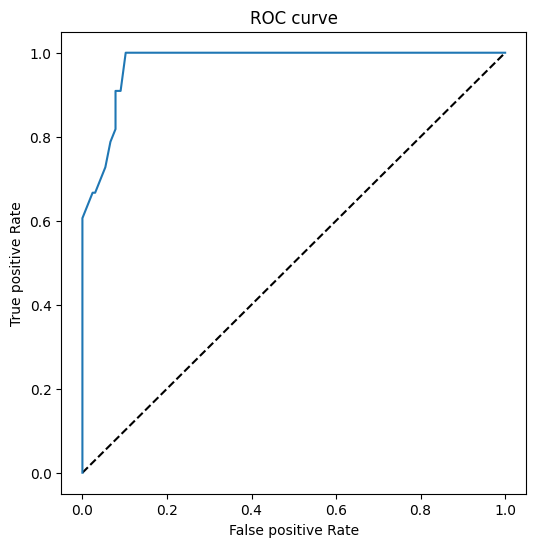

Area under the ROC curve: 0.9749908725812341


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
y_prob = model.predict_proba(x_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])

fig = plt.figure(figsize=(6,6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title('ROC curve')
plt.show()
print(f'Area under the ROC curve: {roc_auc_score(y_test, y_prob[:,1])}')